## Assignment-13        LGBM & XGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'Data\diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

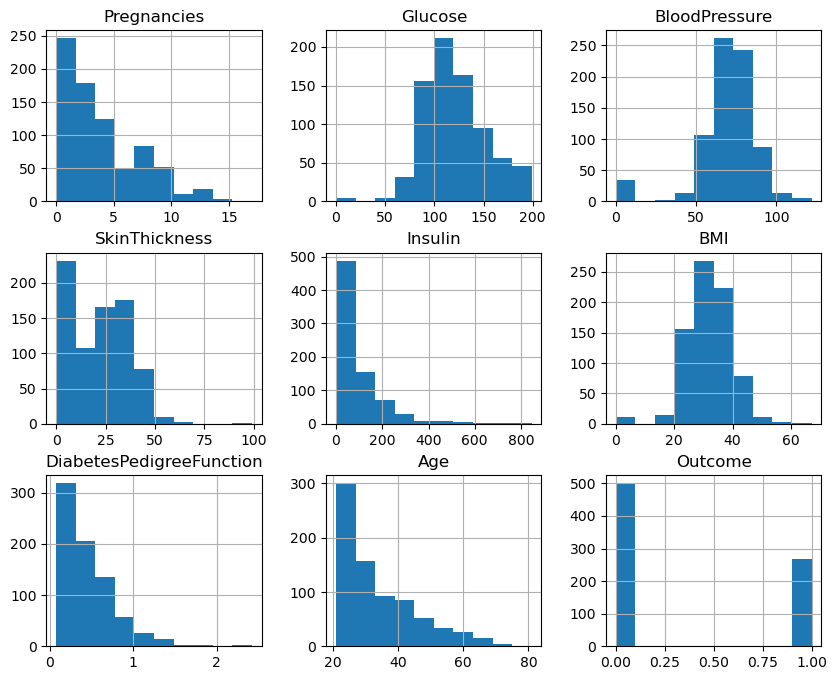

In [7]:
# Histograms

data.hist(figsize=(10,8))
plt.show()

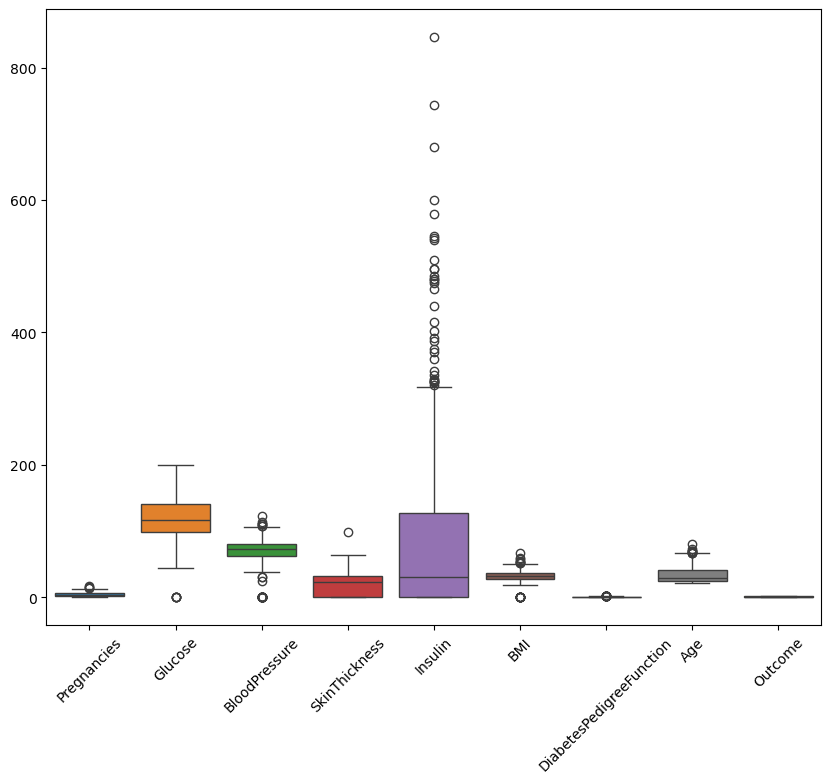

In [8]:
# Boxplots

plt.figure(figsize=(10,8))
sns.boxplot(data)
plt.xticks(rotation=45)
plt.show()

In [9]:
corr = data.corr()
#corr

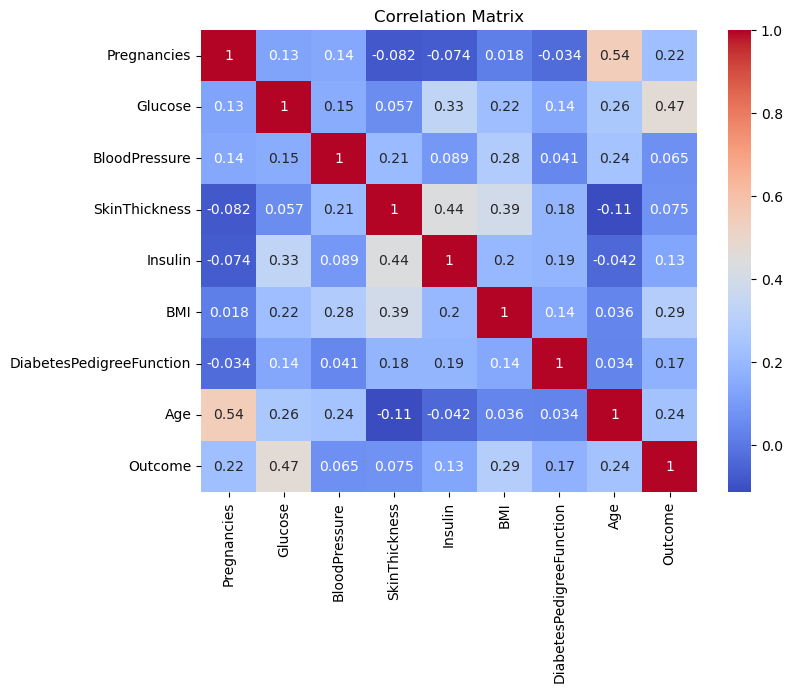

In [10]:
# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(data.corr(),
            annot=True,
            cmap='coolwarm'
           )
plt.title('Correlation Matrix')

plt.show()

In [11]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

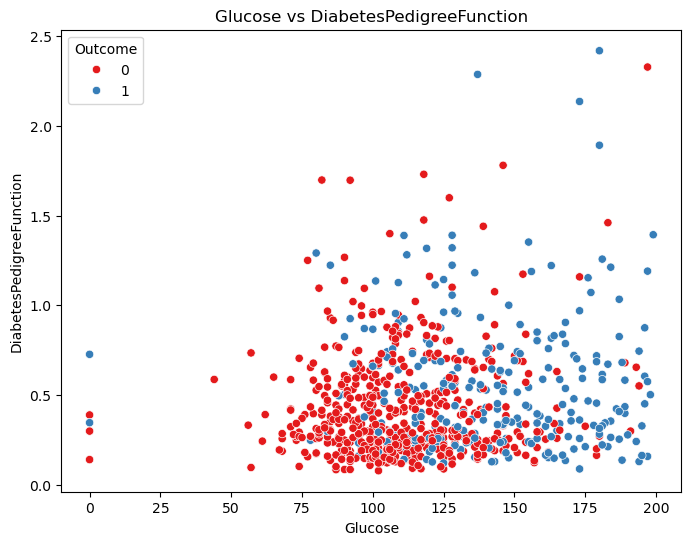

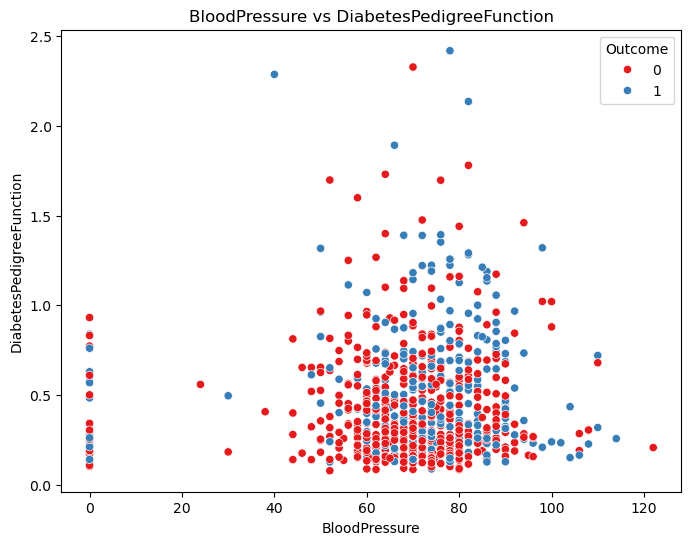

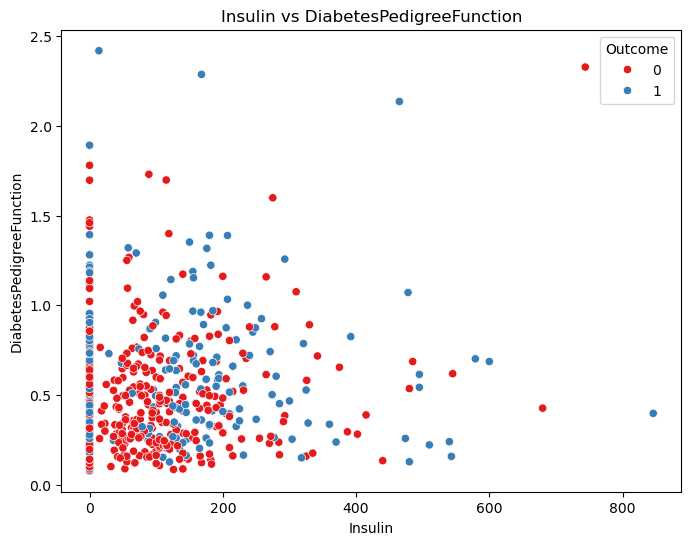

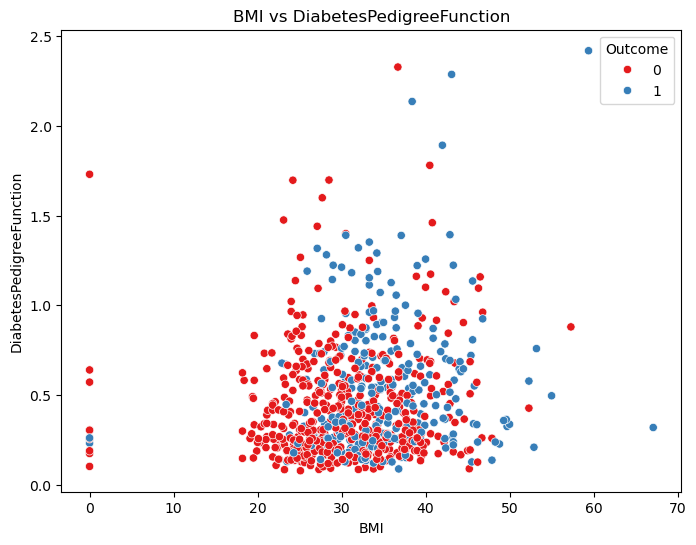

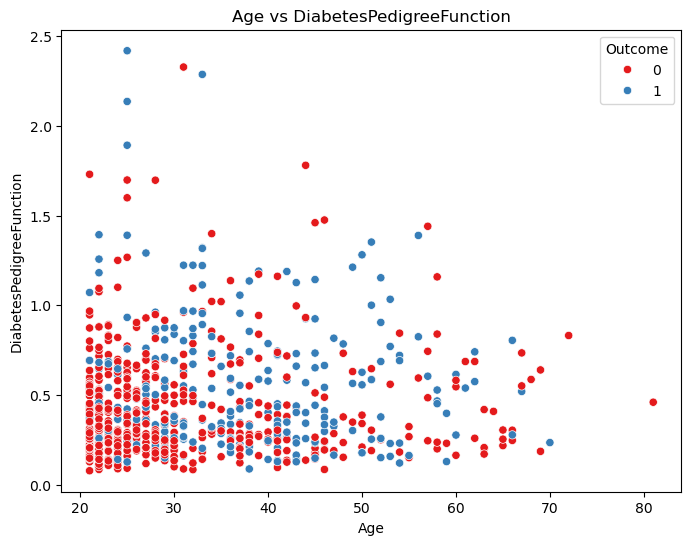

In [12]:
# Scatterplot with Outcome

scatter_features = ['Glucose', 'BloodPressure','Insulin','BMI', 'Age']

for col in scatter_features:
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=data,
                    x = col,
                    y = 'DiabetesPedigreeFunction',
                    hue = 'Outcome',
                    palette='Set1'
    )

    plt.title(f'{col} vs DiabetesPedigreeFunction')

    plt.show()

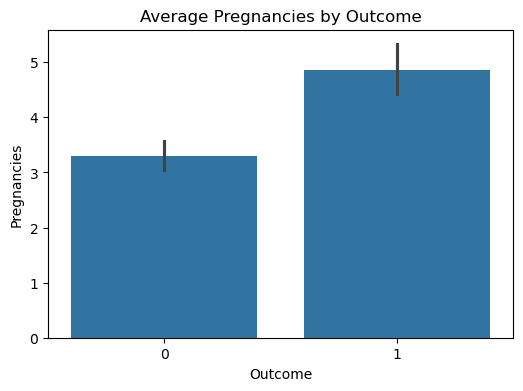

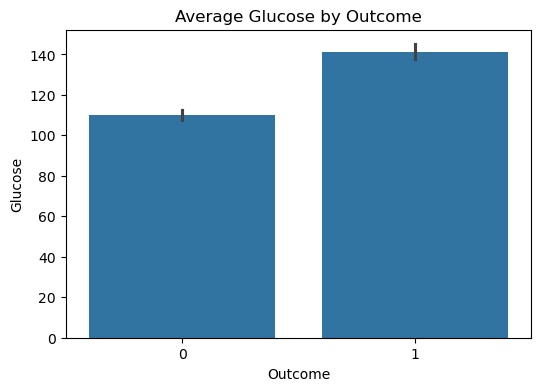

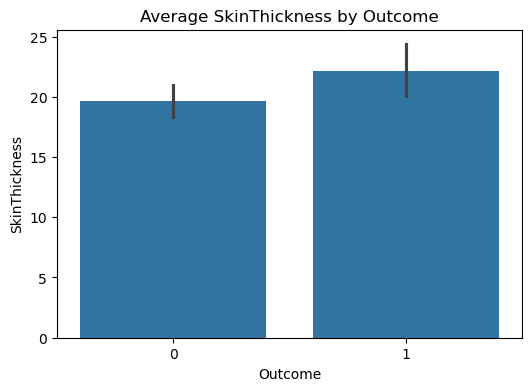

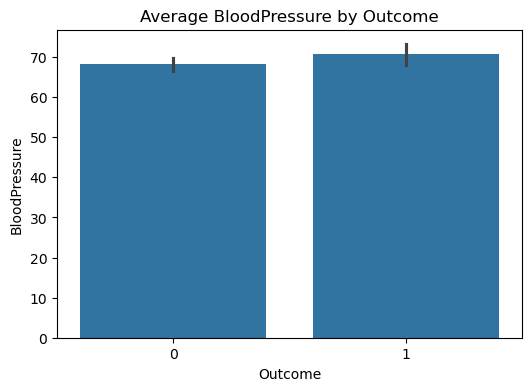

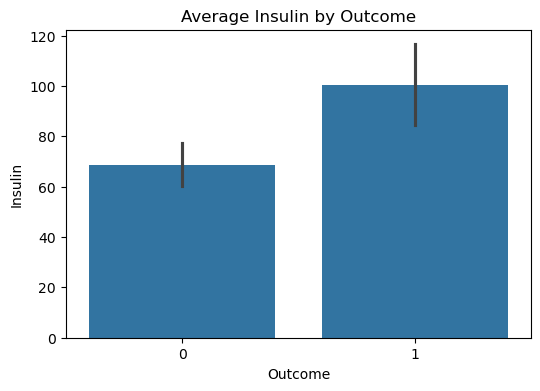

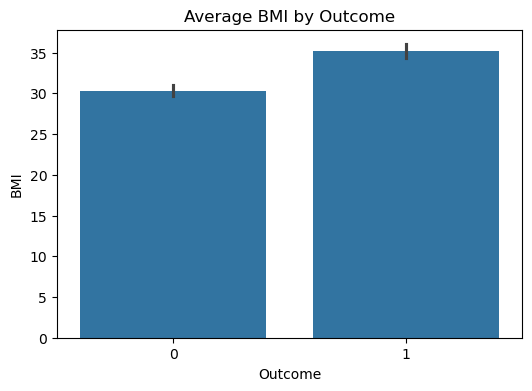

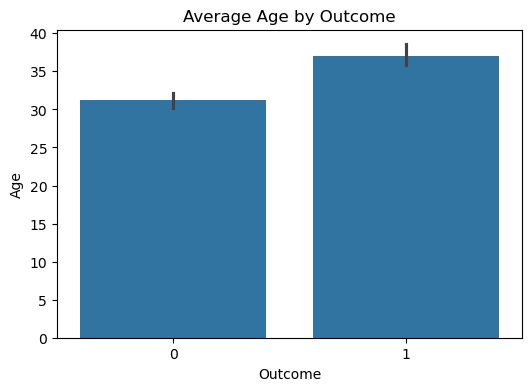

In [13]:
# Barpots (Average values by Outcome)

bar_features = ['Pregnancies', 'Glucose','SkinThickness','BloodPressure','Insulin','BMI','Age']

for col in bar_features:
    plt.figure(figsize=(6,4))
    sns.barplot(data=data,
               x='Outcome',
               y = col
               )
    plt.title(f'Average {col} by Outcome')
    plt.xlabel('Outcome')
    plt.ylabel(col)

    plt.show()

In [14]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

##### Missing Value Imputation

Not required because all columns contain 0 missing values.

##### Encoding

Encoding is not required because there are no categorical (object) columns.

In [15]:
# Scaling

from sklearn.preprocessing import StandardScaler

X = data.drop('Outcome', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
# split features and target

X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [17]:
# split the data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape 

((614, 8), (154, 8), (614,), (154,))

In [18]:
# !pip install xgboost
# !pip install lightgbm

#### LGBM

In [19]:
from lightgbm import LGBMClassifier

In [20]:
lgbm_model = LGBMClassifier(random_state=42,   verbose=-1)

# train the model
lgbm_model.fit(X_train,y_train)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
lgbm_pred = lgbm_model.predict(X_test)

In [37]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [23]:
cm = confusion_matrix(y_test,lgbm_pred)
cm

array([[83, 17],
       [22, 32]])

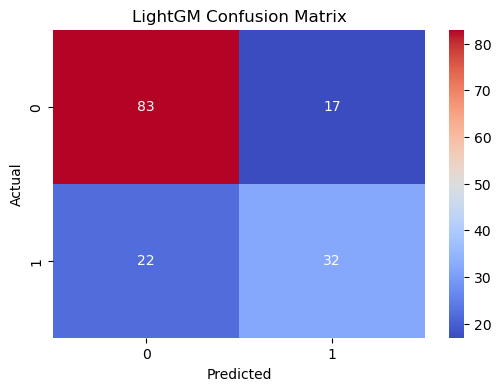

In [24]:
# Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            cmap='coolwarm'
           )
plt.title('LightGM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [25]:
print(classification_report(y_test,lgbm_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



#### XGBM

In [26]:
from xgboost import XGBClassifier

In [27]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# train the model
xgb_model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [28]:
xgb_pred = xgb_model.predict(X_test)

In [29]:
cm = confusion_matrix(y_test,xgb_pred)
cm

array([[80, 20],
       [21, 33]])

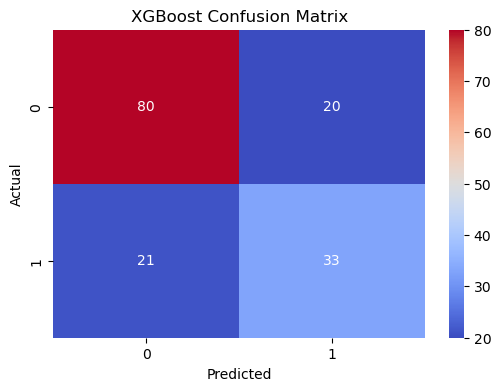

In [30]:
# Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            cmap='coolwarm'
           )
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [31]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



##### Cross validation

In [32]:
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

# Display results
print("Cross Validation Scores:", cv_scores)

print("Mean Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.72727273 0.75974026 0.71428571 0.79084967 0.74509804]
Mean Accuracy: 0.7474492827434004


#### Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV


In [34]:

# Example for XGBoost
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss'), param_grid, cv=3)
grid_xgb.fit(X_train, y_train)

print("Best XGB Params:", grid_xgb.best_params_)

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}


##### Comparing visualizations of both models

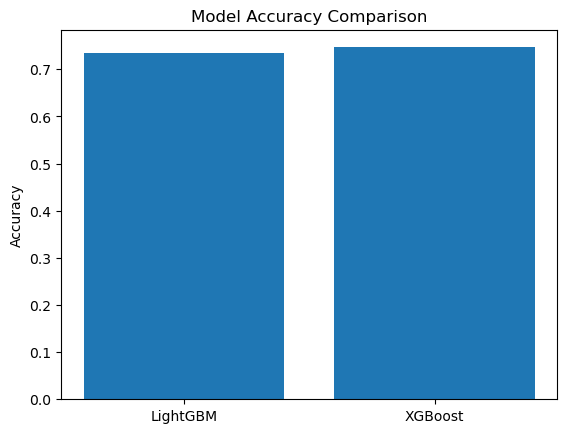

In [40]:
models = [ 'LightGBM', 'XGBoost']
accuracy = [
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, lgbm_pred)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

#### Brief Comparative Analysis Report
##### Title
#### Comparative Analysis of LightGBM and XGBoost for Diabetes Prediction
##### Objective

The objective of this project was to compare the performance of LightGBM and XGBoost on the Pima Indians Diabetes Dataset.

##### Models Used
LightGBM
XGBoost
Evaluation Metrics

##### Observations
#### LightGBM
Faster training time
Efficient memory usage
Suitable for large datasets
#### XGBoost
Higher predictive accuracy
Better handling of complex patterns
Strong regularization capabilities
#### Practical Implications
##### LightGBM is preferred when:
speed is important
dataset size is large
##### XGBoost is preferred when:
maximum accuracy is required
training time is less important
#### Conclusion

Both models performed well for diabetes prediction.

XGBoost generally achieved slightly better predictive performance.
LightGBM provided faster training and computational efficiency.

The choice of model depends on project requirements such as:

accuracy
computational resources
scalability.